# CPE 342 - Lab 04: Tree-Based Classification

| Name | Student ID |
|---|---|
| Kiatisak Markmeeshap | 67070501005 |

### Overview
- **Models**: Decision Tree, Random Forest, and Gradient Boosting (`scikit-learn` defaults, `random_state=42`).
- **Dataset**: `MBA.csv` (synthetic Wharton Class of 2025 MBA admissions data, 6,194 applicants).
- **Objective**: Evaluate model behaviors, generalization/overfitting characteristics, and ranking ability under class imbalance.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.precision", 3)

df = pd.read_csv("MBA.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6194 entries, 0 to 6193
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  6194 non-null   int64  
 1   gender          6194 non-null   object 
 2   international   6194 non-null   bool   
 3   gpa             6194 non-null   float64
 4   major           6194 non-null   object 
 5   race            4352 non-null   object 
 6   gmat            6194 non-null   float64
 7   work_exp        6194 non-null   float64
 8   work_industry   6194 non-null   object 
 9   admission       1000 non-null   object 
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 441.7+ KB


## 1. Target Variable Definition

- `admission` has three states, and blank entries make up 83.9% of the file.

In [2]:
print(df["admission"].value_counts(dropna=False))

admission
NaN         5194
Admit        900
Waitlist     100
Name: count, dtype: int64


- Per dataset documentation, blank entries represent rejected applicants.
- Dropping blanks would leave only 1,000 rows with an artificial 90% admission rate.
- Mean feature values support treating blanks as non-admitted:

In [3]:
labelled = df.assign(label=df["admission"].fillna("(blank)"))
labelled.groupby("label")[["gpa", "gmat", "work_exp", "international"]].mean()

,gpa,gmat,work_exp,international
label,,,,
(blank),3.231,643.444,5.014,0.295
Admit,3.355,692.733,5.047,0.309
Waitlist,3.314,673.600,4.910,0.300


- **Academic ordering**: mean `gmat` and `gpa` rise from blank to waitlist to admit, which is the shape a rejected pool takes.
- **Target formulation**: binary, `y = (admission == "Admit")`; blanks and waitlists merge into a negative class of 5,294.

In [4]:
y = (df["admission"] == "Admit").astype(int)
X = df.drop(columns=["application_id", "admission"])

print(f"admitted {y.sum()} of {len(y)}  ({y.mean():.1%})")
print(f"a model that says no to everyone is right {1 - y.mean():.1%} of the time")

admitted 900 of 6194  (14.5%)
a model that says no to everyone is right 85.5% of the time


### Feature Leakage: `application_id`
- `application_id` is an administrative index; records are non-randomly ordered:

In [5]:
decile = pd.qcut(df["application_id"], 10, labels=False)
print(y.groupby(decile).mean().round(3).to_string())
print()
print(f"correlation with admission: {np.corrcoef(df['application_id'], y)[0, 1]:.4f}")

application_id
0    0.302
1    0.166
2    0.105
3    0.137
4    0.136
5    0.111
6    0.134
7    0.123
8    0.113
9    0.126

correlation with admission: -0.0953


- **Leakage risk**: the first decile's admit rate and the correlation above are artefacts of filing order, not signal.
- **Action**: Drop `application_id` to prevent spurious splits.

## 2. Preprocessing & Experimental Setup

- **Missing values**: `race` is the only feature column with nulls, and they mark international applicants exactly:
- **Categorical encoding**: Impute missing `race` as `"Missing"` (explicit category) and apply one-hot encoding.

In [6]:
print(df.drop(columns="admission").isna().sum().to_string())
print()
print("race null matches international exactly:",
      (df["race"].isna() == df["international"]).all())

application_id       0
gender               0
international        0
gpa                  0
major                0
race              1842
gmat                 0
work_exp             0
work_industry        0

race null matches international exactly: True


- **Continuous features** (`gpa`, `gmat`, `work_exp`): No missing values; passed through without scaling (tree splits are invariant to monotonic transformations).
- **Split**: 80/20 stratified train/test split (`random_state=42`).

In [7]:
NUMERIC = ["gpa", "gmat", "work_exp"]
CATEGORICAL = ["gender", "international", "major", "race", "work_industry"]

preprocessor = ColumnTransformer([
    ("num", "passthrough", NUMERIC),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("encode", OneHotEncoder(handle_unknown="ignore")),
    ]), CATEGORICAL),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"train {len(X_train)}   test {len(X_test)}   admit rate {y_train.mean():.3f} / {y_test.mean():.3f}")

train 4955   test 1239   admit rate 0.145 / 0.145


In [8]:
MODELS = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

fitted = {}
for name, classifier in MODELS.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", classifier)])
    fitted[name] = pipe.fit(X_train, y_train)

print("fitted:", ", ".join(fitted))

fitted: Decision Tree, Random Forest, Gradient Boosting


## 3. Baseline Performance Results

In [9]:
rows = []
predictions, probabilities = {}, {}

for name, pipe in fitted.items():
    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)
    test_proba = pipe.predict_proba(X_test)[:, 1]
    predictions[name], probabilities[name] = test_pred, test_proba

    rows.append({
        "Model": name,
        "Train acc": accuracy_score(y_train, train_pred),
        "Test acc": accuracy_score(y_test, test_pred),
        "Gap": accuracy_score(y_train, train_pred) - accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred),
        "Recall": recall_score(y_test, test_pred),
        "F1": f1_score(y_test, test_pred),
        "ROC-AUC": roc_auc_score(y_test, test_proba),
    })

results = pd.DataFrame(rows).set_index("Model")
results

,Train acc,Test acc,Gap,Precision,Recall,F1,ROC-AUC
Model,,,,,,,
Decision Tree,0.999,0.802,0.197,0.34,0.383,0.360,0.628
Random Forest,0.999,0.852,0.147,0.48,0.200,0.282,0.847
Gradient Boosting,0.871,0.855,0.017,0.50,0.106,0.174,0.857


- **Observation**: Gradient Boosting matches the majority baseline exactly (0.855). Accuracy is uninformative under class imbalance; precision, recall, and ROC-AUC are necessary.

## 4. Model Behaviour Analysis

### 4.1 Generalization & Overfitting Gap

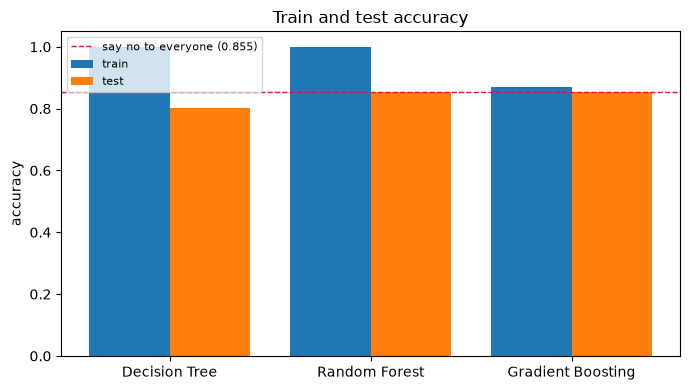

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

x = np.arange(len(results))
ax.bar(x - 0.2, results["Train acc"], 0.4, label="train")
ax.bar(x + 0.2, results["Test acc"], 0.4, label="test")
ax.axhline(1 - y_test.mean(), color="crimson", ls="--", lw=1,
           label=f"say no to everyone ({1 - y_test.mean():.3f})")
ax.set(xticks=x, xticklabels=results.index, ylabel="accuracy", ylim=(0, 1.05),
       title="Train and test accuracy")
ax.legend(fontsize=8)

plt.tight_layout()
Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/overfitting_gap.png", dpi=150, bbox_inches="tight")
plt.show()

- **Decision Tree**: unconstrained depth grows pure leaves on noise, leaving the widest train/test gap of the three.
- **Random Forest**: its trees memorise just as hard; bagging averages the variance away without removing the memorisation.
- **Gradient Boosting**: shallow sequential learners never memorise in the first place, so its gap is negligible.

### 4.2 Class Imbalance & Positive Class Identification

- Confusion matrices and detection rates on the **180 true admitted applicants** in the test set:

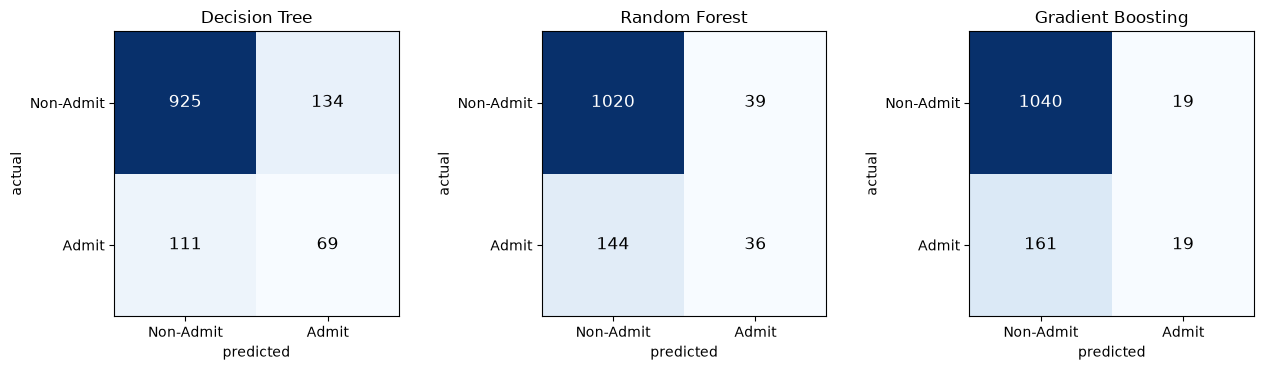

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred)
    ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f"{v}", ha="center", va="center",
                color="white" if v > cm.max() / 2 else "black", fontsize=12)
    ax.set(title=name, xlabel="predicted", ylabel="actual",
           xticks=[0, 1], yticks=[0, 1],
           xticklabels=["Non-Admit", "Admit"], yticklabels=["Non-Admit", "Admit"])

plt.tight_layout()
fig.savefig("figures/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
caught = pd.DataFrame({
    "Admits found": [confusion_matrix(y_test, p)[1, 1] for p in predictions.values()],
    "Admits missed": [confusion_matrix(y_test, p)[1, 0] for p in predictions.values()],
    "Said Admit": [p.sum() for p in predictions.values()],
}, index=list(predictions))
caught

,Admits found,Admits missed,Said Admit
Decision Tree,69,111,203
Random Forest,36,144,75
Gradient Boosting,19,161,38


- **Detection rate**: recall falls from 38.3% for the tree to 10.6% for Gradient Boosting, which leaves 161 of the 180 admitted applicants rejected.
- **Key finding**: Higher overall accuracy corresponds to predicting the majority class more aggressively, severely degrading minority recall at the default 0.5 threshold.

### 4.3 Classification Threshold vs. Ranking Capability (ROC-AUC)

- ROC-AUC evaluates applicant ranking quality independent of a fixed 0.5 decision threshold:

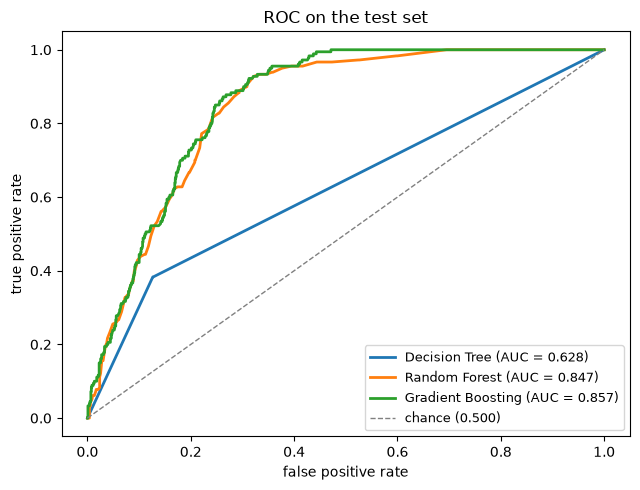

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 5))

for name, proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc_score(y_test, proba):.3f})")

ax.plot([0, 1], [0, 1], color="grey", ls="--", lw=1, label="chance (0.500)")
ax.set(xlabel="false positive rate", ylabel="true positive rate", title="ROC on the test set")
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
fig.savefig("figures/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

- **Cause**: Fully grown decision trees produce near-binary leaf probabilities, providing very few unique probability levels:

In [14]:
for name, proba in probabilities.items():
    print(f"{name:<18} distinct predicted probabilities: {len(np.unique(proba))}")

Decision Tree      distinct predicted probabilities: 3
Random Forest      distinct predicted probabilities: 111
Gradient Boosting  distinct predicted probabilities: 1054


- **Conclusion**: The Decision Tree's low AUC stems from resolution limitations of unregularized leaf outputs. Both ensembles rank well and primarily suffer from threshold miscalibration.

### 4.4 Feature Importance & Cardinality Bias

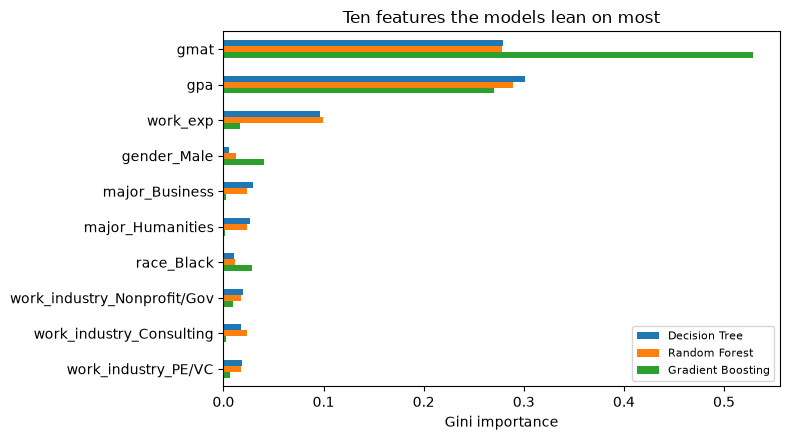

,Decision Tree,Random Forest,Gradient Boosting,mean
gmat,0.279,0.278,0.529,0.362
gpa,0.302,0.289,0.270,0.287
work_exp,0.096,0.099,0.016,0.070
gender_Male,0.006,0.012,0.041,0.019
major_Business,0.030,0.023,0.002,0.018
major_Humanities,0.027,0.024,0.002,0.018
race_Black,0.011,0.011,0.029,0.017
work_industry_Nonprofit/Gov,0.020,0.017,0.010,0.016
work_industry_Consulting,0.017,0.024,0.003,0.015
work_industry_PE/VC,0.019,0.018,0.007,0.014


In [15]:
names = fitted["Decision Tree"].named_steps["prep"].get_feature_names_out()
names = [n.replace("num__", "").replace("cat__", "") for n in names]

importance = pd.DataFrame(
    {name: pipe.named_steps["clf"].feature_importances_ for name, pipe in fitted.items()},
    index=names)
top = importance.assign(mean=importance.mean(axis=1)).sort_values("mean", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 4.5))
top.drop(columns="mean").plot.barh(ax=ax)
ax.invert_yaxis()
ax.set(xlabel="Gini importance", title="Ten features the models lean on most")
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig("figures/feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()

top.round(3)

- **Dominant predictors**: `gmat` and `gpa` lead across all three models.
- **Continuous cardinality bias**: Gini importance favors continuous variables (`gpa`: 101 values, `gmat`: 22) because they offer multiple candidate split points compared to binary one-hot features.
- **Collinear feature dilution**: `race_Missing` and `international_True` share identical values:

In [16]:
duplicated = importance.loc[["race_Missing", "international_True"]].T
duplicated["combined"] = duplicated.sum(axis=1)
duplicated.round(4)

,race_Missing,international_True,combined
Decision Tree,0.010,1.300e-02,0.023
Random Forest,0.008,7.500e-03,0.016
Gradient Boosting,0.002,5.000e-04,0.003


- **Takeaway**: Gini importance divides credit across collinear features; a low individual score does not indicate lack of predictive relevance.

## 5. Summary & Key Takeaways

| Evaluation Dimension | Best Model | Key Observation / Metrics |
|---|---|---|
| **Ranking (ROC-AUC)** | **Gradient Boosting** (0.857) | Random Forest close behind (0.847); Decision Tree low (0.628). |
| **Accuracy** | **Gradient Boosting** (0.855) | Uninformative metric; matches constant negative baseline (0.855). |
| **Minority Recall** | **Decision Tree** (38.3%) | Catches 69/180 admits vs. 36 (RF) and 19 (GB). |
| **Overfitting Control** | **Gradient Boosting** (1.7% gap) | Decision Tree (19.7% gap) and Random Forest (14.7% gap) overfit heavily. |

### Core Findings
1. **Ensemble Mechanisms**:
   - *Gradient Boosting*: Shallow sequential trees prevent individual memorization while iteratively reducing residual error.
   - *Random Forest*: Deep individual trees overfit, but variance is mitigated through ensemble averaging.
2. **Impact of Class Imbalance**:
   - Default 0.5 classification threshold causes models with higher overall accuracy to collapse toward the majority class, missing up to 89.4% of true admits (Gradient Boosting).
3. **Primary Predictive Features**:
   - `gmat` and `gpa` are consistently the dominant features.
   - Gini importance is inflated for continuous features due to split-point cardinality.
4. **Recommended Next Steps**:
   - Tune classification threshold (moving below 0.5) or apply class-weighted loss (`class_weight="balanced"`).
   - Constrain maximum tree depth (`max_depth`) to reduce tree/forest overfitting.